# EMA Trend-Following Research

Stage 3 explores the signal logic of a long-only EMA20 / EMA50 strategy on the existing Bybit spot BTCUSDT hourly snapshot. This notebook defines signals and a research state; it does not execute trades, calculate PnL, or simulate a portfolio. All derived columns stay in memory.

## 1. Strategy Definition

- Fast EMA: 20 hourly closes; slow EMA: 50 hourly closes.
- EMA20 above EMA50 describes a bullish regime; EMA20 below EMA50 describes a non-bullish regime.
- **Bullish crossover:** previous EMA20 <= previous EMA50, and current EMA20 > current EMA50. Emit `LONG_ENTRY`.
- **Bearish crossover:** previous EMA20 >= previous EMA50, and current EMA20 < current EMA50. Emit `LONG_EXIT`.
- Otherwise emit `HOLD`, keeping the existing state. Equality on the current row produces no event.
- Start flat: `0` means flat and `1` means long. There are no short positions.

A crossover is a change in the relationship between two averages, not every row in a bullish regime. A signal describes a research decision. It is different from an exchange order or a confirmed fill.

These spans are initial research parameters, not proven optimal choices. Signals use completed candle closes, so future execution must wait until at least the next candle.

## 2. Imports

Use the existing pandas, Matplotlib, and Jupyter environment. The project uses a `src/` layout; adding it to the import path lets this notebook call the reusable OHLCV loader instead of duplicating API logic. Python's `hashlib` will verify that the CSV stays unchanged.

The existing requests import can emit an urllib3/LibreSSL warning. It is not suppressed; loading the available snapshot requires no HTTP request.

In [1]:
from pathlib import Path
import hashlib
import sys

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import (
    download_ohlcv,
    load_ohlcv_csv,
    save_ohlcv,
    validate_ohlcv,
)

Matplotlib is building the font cache; this may take a moment.


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 3. Load Historical Data

Read the existing six-column CSV and validate its UTC timestamps, numeric values, OHLC consistency, and hourly coverage. Only if the file is missing may the existing loader download the same historical period. Saving refuses to overwrite an existing raw file.

`raw_df` remains the original normalized market data. `df` is a separate in-memory copy for EMA and signal research. No derived data is exported.

In [2]:
START = "2025-10-01T00:00:00Z"
END = "2026-10-01T00:00:00Z"  # Exclusive.
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"

if CSV_PATH.exists():
    raw_df = load_ohlcv_csv(CSV_PATH, start=START, end=END)
    print("Loaded existing snapshot:", CSV_PATH)
else:
    raw_df = download_ohlcv(start=START, end=END)
    save_ohlcv(raw_df, CSV_PATH)
    print("Downloaded missing snapshot:", CSV_PATH)

raw_hash_before = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
quality = validate_ohlcv(raw_df, start=START, end=END)
df = raw_df.copy()

print("Rows:", len(raw_df))
print("Candle opening range:", raw_df["timestamp"].min(), "to", raw_df["timestamp"].max())
print("Raw columns:", raw_df.columns.tolist())
display(raw_df.dtypes)
display(quality)
display(raw_df.head())

Loaded existing snapshot: /Users/romankondratenko/trading-lab/Trading Lab/data/raw/BTCUSDT_1h.csv
Rows: 8760
Candle opening range: 2025-10-01 00:00:00+00:00 to 2026-09-30 23:00:00+00:00
Raw columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']


timestamp    datetime64[ns, UTC]
open                     float64
high                     float64
low                      float64
close                    float64
volume                   float64
dtype: object

{'rows': 8760,
 'earliest_timestamp': Timestamp('2025-10-01 00:00:00+0000', tz='UTC'),
 'latest_timestamp': Timestamp('2026-09-30 23:00:00+0000', tz='UTC'),
 'missing_values': {'timestamp': 0,
  'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'volume': 0},
 'duplicate_timestamps': 0,
 'chronological': True,
 'invalid_ohlc_rows': 0,
 'missing_candles': 0}

,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905
3,2025-10-01 03:00:00+00:00,114275.5,114533.5,114100.1,114178.1,296.903591
4,2025-10-01 04:00:00+00:00,114178.1,114710.2,114140.7,114291.0,280.776000


## 4. Calculate EMA20 and EMA50

An exponential moving average (EMA) is a smoothed price that gives more weight to recent observations. For `adjust=False`, pandas uses a recursive calculation: `current EMA = alpha * current close + (1 - alpha) * previous EMA`, where `alpha = 2 / (span + 1)`.

A smaller span gives the current close more weight, so EMA20 usually reacts faster than EMA50. A span is a weighting parameter, not a hard window that drops every older observation.

Both averages start at the first observed close. We use pandas' default availability from the first observation, with no 50-candle warm-up filter. The first EMAs are equal; the first row cannot be a crossover because it has no preceding row. Early events are sensitive to this initialization. A future warm-up rule would change the strategy definition and must be explicit.

In [3]:
FAST_SPAN = 20
SLOW_SPAN = 50

df["ema_20"] = df["close"].ewm(span=FAST_SPAN, adjust=False).mean()
df["ema_50"] = df["close"].ewm(span=SLOW_SPAN, adjust=False).mean()

df[["timestamp", "close", "ema_20", "ema_50"]].head()

,timestamp,close,ema_20,ema_50
0,2025-10-01 00:00:00+00:00,114241.0,114241.000000,114241.000000
1,2025-10-01 01:00:00+00:00,114549.4,114270.371429,114253.094118
2,2025-10-01 02:00:00+00:00,114275.5,114270.859864,114253.972780
3,2025-10-01 03:00:00+00:00,114178.1,114262.025591,114250.997377
4,2025-10-01 04:00:00+00:00,114291.0,114264.785059,114252.566107


## 5. Detect Crossovers

`shift(1)` puts each preceding EMA beside the current row. Compare the previous relationship with the current relationship to detect an event. The first shifted values are missing, so its comparisons do not produce a crossover.

The previous relationship includes equality, exactly as defined above; the current comparison is strict. These are events known after the current candle closes.

In [4]:
previous_fast = df["ema_20"].shift(1)
previous_slow = df["ema_50"].shift(1)

was_at_or_below = previous_fast <= previous_slow
is_above = df["ema_20"] > df["ema_50"]
df["bullish_cross"] = was_at_or_below & is_above

was_at_or_above = previous_fast >= previous_slow
is_below = df["ema_20"] < df["ema_50"]
df["bearish_cross"] = was_at_or_above & is_below

print("Bullish crossovers:", df["bullish_cross"].sum())
print("Bearish crossovers:", df["bearish_cross"].sum())

Bullish crossovers: 79
Bearish crossovers: 78


## 6. Generate Signals

Initialize every row to `HOLD`. Change only bullish event rows to `LONG_ENTRY` and bearish event rows to `LONG_EXIT`. `.loc` selects the rows matching each Boolean mask.

These strings express research intent. They do not create BUY/SELL orders or execution prices.

In [5]:
df["signal"] = "HOLD"
df.loc[df["bullish_cross"], "signal"] = "LONG_ENTRY"
df.loc[df["bearish_cross"], "signal"] = "LONG_EXIT"

df["signal"].value_counts()

signal
HOLD          8603
LONG_ENTRY      79
LONG_EXIT       78
Name: count, dtype: int64

## 7. Build Position State

Begin flat and process signals chronologically. An entry sets the research state to 1, an exit sets it to 0, and HOLD preserves the previous state. The explicit loop makes this state transition easy to follow.

`position` means the intended state **after processing the signal at this candle's close**. It is not the position held throughout that candle or evidence of a trade at its close. Applying an event to an already matching state would keep it unchanged; no extra order is modeled.

In [6]:
current_position = 0
positions = []

for signal in df["signal"]:
    if signal == "LONG_ENTRY":
        current_position = 1
    elif signal == "LONG_EXIT":
        current_position = 0
    # HOLD leaves current_position unchanged.
    positions.append(current_position)

df["position"] = positions
print("Final research position:", df["position"].iloc[-1], "(0 = flat, 1 = long)")

Final research position: 1 (0 = flat, 1 = long)


## 8. Visualize Strategy Logic

Plot close price and both EMAs, with upward markers for bullish crossovers and downward markers for bearish crossovers. Markers are placed on the candle close price only as visual annotations; they are not fills or execution prices.

The full-period chart shows overall behavior. The smaller February window makes the relationships and crossover events easier to inspect. Its dates select a visual example, not a parameter optimization or performance result.

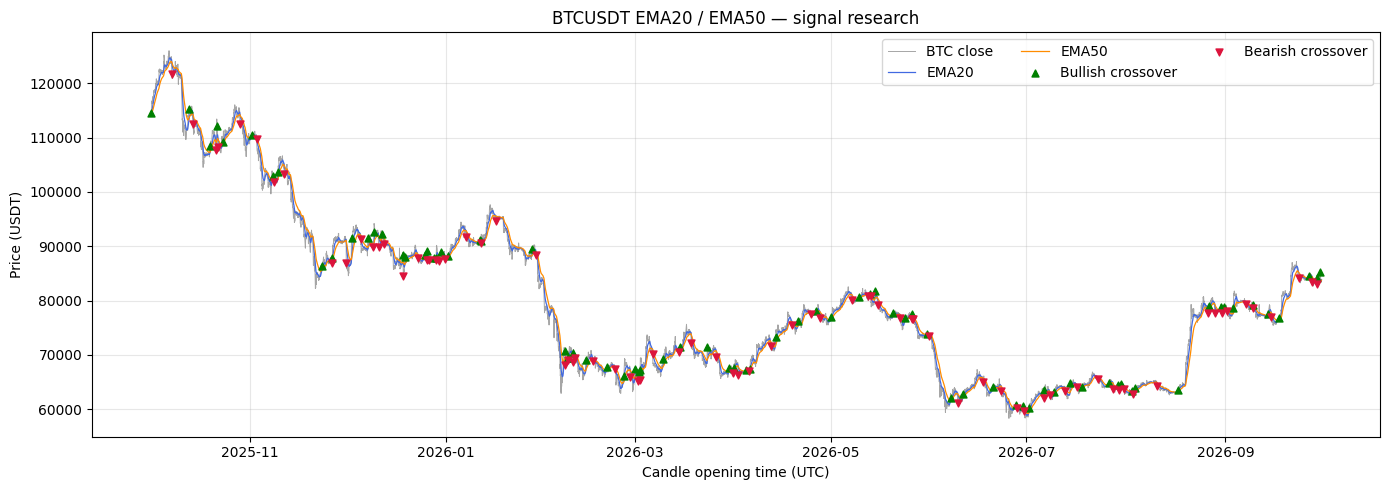

In [7]:
entry_rows = df.loc[df["bullish_cross"]]
exit_rows = df.loc[df["bearish_cross"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["timestamp"], df["close"], label="BTC close", color="gray", linewidth=0.7, alpha=0.7)
ax.plot(df["timestamp"], df["ema_20"], label="EMA20", color="royalblue", linewidth=0.9)
ax.plot(df["timestamp"], df["ema_50"], label="EMA50", color="darkorange", linewidth=0.9)
ax.scatter(entry_rows["timestamp"], entry_rows["close"], marker="^", color="green", s=25, label="Bullish crossover", zorder=4)
ax.scatter(exit_rows["timestamp"], exit_rows["close"], marker="v", color="crimson", s=25, label="Bearish crossover", zorder=4)
ax.set(title="BTCUSDT EMA20 / EMA50 — signal research", xlabel="Candle opening time (UTC)", ylabel="Price (USDT)")
ax.legend(ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

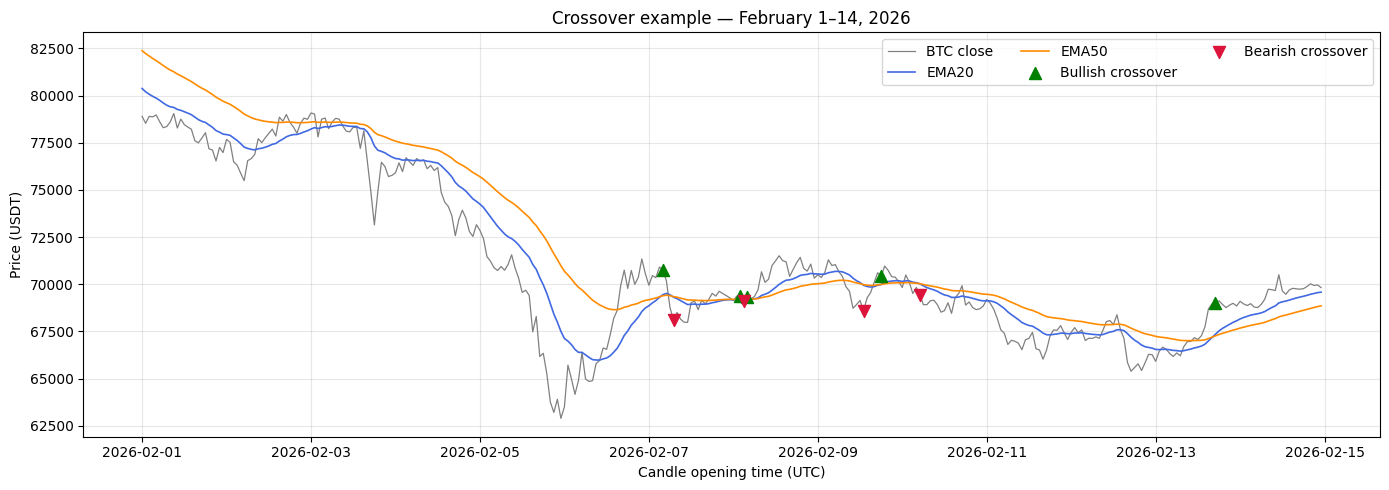

In [8]:
ZOOM_START = pd.Timestamp("2026-02-01", tz="UTC")
ZOOM_END = pd.Timestamp("2026-02-15", tz="UTC")
zoom = df.loc[(df["timestamp"] >= ZOOM_START) & (df["timestamp"] < ZOOM_END)]
zoom_entries = zoom.loc[zoom["bullish_cross"]]
zoom_exits = zoom.loc[zoom["bearish_cross"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom["timestamp"], zoom["close"], label="BTC close", color="gray", linewidth=0.9)
ax.plot(zoom["timestamp"], zoom["ema_20"], label="EMA20", color="royalblue", linewidth=1.2)
ax.plot(zoom["timestamp"], zoom["ema_50"], label="EMA50", color="darkorange", linewidth=1.2)
ax.scatter(zoom_entries["timestamp"], zoom_entries["close"], marker="^", color="green", s=75, label="Bullish crossover", zorder=4)
ax.scatter(zoom_exits["timestamp"], zoom_exits["close"], marker="v", color="crimson", s=75, label="Bearish crossover", zorder=4)
ax.set(title="Crossover example — February 1–14, 2026", xlabel="Candle opening time (UTC)", ylabel="Price (USDT)")
ax.legend(ncol=3)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Inspect Signal Examples

Inspect two rows before and after the first bullish event, the first bearish event, and a later bullish event. For each event, compare the preceding EMA relationship with the current one, then verify its signal and post-close research state. The seed event has fewer preceding rows because it occurs near the snapshot's start.

During an entry, the previous fast EMA must be at or below the slow EMA and the current fast EMA must be above it. The reverse comparisons identify an exit. HOLD rows must preserve state.

In [9]:
inspection_columns = [
    "timestamp", "close", "ema_20", "ema_50", "bullish_cross", "bearish_cross", "signal", "position"
]
bullish_indices = df.index[df["bullish_cross"]]
bearish_indices = df.index[df["bearish_cross"]]
example_indices = [
    bullish_indices[0],
    bearish_indices[0],
    bullish_indices[len(bullish_indices) // 2],
]

for event_index in example_indices:
    first_row = max(0, event_index - 2)
    last_row = min(len(df), event_index + 3)
    example = df.iloc[first_row:last_row][inspection_columns]
    print("Event:", df.loc[event_index, "timestamp"], df.loc[event_index, "signal"])
    display(example.style.format({"close": "{:.2f}", "ema_20": "{:.6f}", "ema_50": "{:.6f}"}))

Event: 2025-10-01 01:00:00+00:00 LONG_ENTRY


,timestamp,close,ema_20,ema_50,bullish_cross,bearish_cross,signal,position
0,2025-10-01 00:00:00+00:00,114241.00,114241.000000,114241.000000,False,False,HOLD,0
1,2025-10-01 01:00:00+00:00,114549.40,114270.371429,114253.094118,True,False,LONG_ENTRY,1
2,2025-10-01 02:00:00+00:00,114275.50,114270.859864,114253.972780,False,False,HOLD,1
3,2025-10-01 03:00:00+00:00,114178.10,114262.025591,114250.997377,False,False,HOLD,1


Event: 2025-10-07 16:00:00+00:00 LONG_EXIT


,timestamp,close,ema_20,ema_50,bullish_cross,bearish_cross,signal,position
158,2025-10-07 14:00:00+00:00,122735.40,124208.296806,123976.932237,False,False,HOLD,1
159,2025-10-07 15:00:00+00:00,121855.40,123984.211396,123893.734894,False,False,HOLD,1
160,2025-10-07 16:00:00+00:00,121729.00,123769.429358,123808.843330,False,True,LONG_EXIT,0
161,2025-10-07 17:00:00+00:00,121148.90,123519.855134,123704.531827,False,False,HOLD,0
162,2025-10-07 18:00:00+00:00,120892.10,123269.592740,123594.240382,False,False,HOLD,0


Event: 2026-03-31 17:00:00+00:00 LONG_ENTRY


,timestamp,close,ema_20,ema_50,bullish_cross,bearish_cross,signal,position
4359,2026-03-31 15:00:00+00:00,66741.20,66978.530341,67036.227574,False,False,HOLD,0
4360,2026-03-31 16:00:00+00:00,67675.40,67044.898880,67061.293159,False,False,HOLD,0
4361,2026-03-31 17:00:00+00:00,67532.90,67091.375177,67079.787545,True,False,LONG_ENTRY,1
4362,2026-03-31 18:00:00+00:00,67853.20,67163.929922,67110.117445,False,False,HOLD,1
4363,2026-03-31 19:00:00+00:00,67834.10,67227.755644,67138.508918,False,False,HOLD,1


## 10. Timing and Look-Ahead Bias

OHLCV timestamps mark candle **opening** times. For an hourly candle, its close and the resulting EMA signal become available at `timestamp + 1 hour`; we call that `signal_time`.

For example, a candle opening at 01:00 UTC supplies its final close at 02:00 UTC. The next candle opens at that boundary. Future execution must occur no earlier than that next candle, after the signal is available. An eventual simulator must define its execution convention and information availability separately.

Look-ahead bias means using information that was not yet known at the simulated decision time. Treating a candle's final EMA as available at its opening, or pretending an order fills at the same close that generated its signal, would create misleading results.

EMA calculations use past and current completed closes, and crossover comparisons use the previous row. `position` is a post-signal research state. There are no execution prices or fills in this notebook.

In [10]:
df["signal_time"] = df["timestamp"] + pd.Timedelta(hours=1)
signal_events = df.loc[df["signal"] != "HOLD", ["timestamp", "signal_time", "signal", "position"]]
print("Candle opening timestamp versus signal availability:")
signal_events.head()

Candle opening timestamp versus signal availability:


,timestamp,signal_time,signal,position
1,2025-10-01 01:00:00+00:00,2025-10-01 02:00:00+00:00,LONG_ENTRY,1
160,2025-10-07 16:00:00+00:00,2025-10-07 17:00:00+00:00,LONG_EXIT,0
290,2025-10-13 02:00:00+00:00,2025-10-13 03:00:00+00:00,LONG_ENTRY,1
317,2025-10-14 05:00:00+00:00,2025-10-14 06:00:00+00:00,LONG_EXIT,0
447,2025-10-19 15:00:00+00:00,2025-10-19 16:00:00+00:00,LONG_ENTRY,1


## 11. Validation Checks

Use lightweight assertions to check mutually exclusive crossover events, signal consistency, flat/long-only state, correct transitions, chronological timestamps, timing, and preservation of raw data.

Also recompute the first half of the EMAs using only that prefix. Its results must match the same rows in the full calculation, confirming that later candles are not needed for those historical EMA values. These checks validate signal mechanics, not profitability.

In [11]:
assert not (df["bullish_cross"] & df["bearish_cross"]).any()
assert df["signal"].isin(["LONG_ENTRY", "LONG_EXIT", "HOLD"]).all()
assert df["signal"].eq("LONG_ENTRY").equals(df["bullish_cross"])
assert df["signal"].eq("LONG_EXIT").equals(df["bearish_cross"])
assert df["position"].isin([0, 1]).all()
assert df["position"].ge(0).all()  # No shorts.
assert df["position"].iloc[0] == 0
assert df["signal"].iloc[0] == "HOLD"

previous_position = df["position"].shift(1, fill_value=0)
position_changes = df["position"] != previous_position
assert df.loc[position_changes, "signal"].ne("HOLD").all()
assert df.loc[df["signal"] == "LONG_ENTRY", "position"].eq(1).all()
assert df.loc[df["signal"] == "LONG_EXIT", "position"].eq(0).all()
hold_rows = df["signal"] == "HOLD"
assert df.loc[hold_rows, "position"].equals(previous_position.loc[hold_rows])
assert df.loc[df["bullish_cross"], "ema_20"].gt(df.loc[df["bullish_cross"], "ema_50"]).all()
assert previous_fast.loc[df["bullish_cross"]].le(previous_slow.loc[df["bullish_cross"]]).all()
assert df.loc[df["bearish_cross"], "ema_20"].lt(df.loc[df["bearish_cross"], "ema_50"]).all()
assert previous_fast.loc[df["bearish_cross"]].ge(previous_slow.loc[df["bearish_cross"]]).all()
assert df["timestamp"].is_monotonic_increasing
assert df["timestamp"].is_unique
assert df["signal_time"].eq(df["timestamp"] + pd.Timedelta(hours=1)).all()

prefix_end = len(df) // 2
prefix_closes = df["close"].iloc[:prefix_end]
for span, column in [(FAST_SPAN, "ema_20"), (SLOW_SPAN, "ema_50")]:
    prefix_ema = prefix_closes.ewm(span=span, adjust=False).mean()
    pd.testing.assert_series_equal(prefix_ema, df[column].iloc[:prefix_end], check_names=False)

pd.testing.assert_frame_equal(raw_df, df[raw_df.columns])
assert hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before
validate_ohlcv(raw_df, start=START, end=END)
validation_passed = True
print("All signal, state, timing, causal-prefix, and raw-preservation checks passed.")

All signal, state, timing, causal-prefix, and raw-preservation checks passed.


## 12. Strategy Summary

Report crossover counts, first events, and the final post-signal state. The first event times below include both the candle opening label and when the completed-candle signal becomes available.

In [12]:
bullish_count = int(df["bullish_cross"].sum())
bearish_count = int(df["bearish_cross"].sum())
first_bullish = df.loc[df["bullish_cross"], ["timestamp", "signal_time"]].iloc[0]
first_bearish = df.loc[df["bearish_cross"], ["timestamp", "signal_time"]].iloc[0]
final_position = int(df["position"].iloc[-1])

print("Bullish crossovers:", bullish_count)
print("Bearish crossovers:", bearish_count)
print("First bullish candle:", first_bullish["timestamp"], "signal available:", first_bullish["signal_time"])
print("First bearish candle:", first_bearish["timestamp"], "signal available:", first_bearish["signal_time"])
print("Final research position:", final_position, "(0 = flat, 1 = long)")
print("Validation passed:", validation_passed)
print("Raw CSV unchanged:", hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before)

Bullish crossovers: 79
Bearish crossovers: 78
First bullish candle: 2025-10-01 01:00:00+00:00 signal available: 2025-10-01 02:00:00+00:00
First bearish candle: 2025-10-07 16:00:00+00:00 signal available: 2025-10-07 17:00:00+00:00
Final research position: 1 (0 = flat, 1 = long)
Validation passed: True
Raw CSV unchanged: True


The fixed 8,760-candle snapshot produces **79 bullish** and **78 bearish** crossover events, ending in research state **1 (long)**. The first bullish candle opens at **2025-10-01 01:00 UTC**, with its signal available at **02:00 UTC**; the first bearish candle opens at **2025-10-07 16:00 UTC**, with its signal available at **17:00 UTC**.

The first entry follows equality at EMA initialization, so the early event should not be confused with a fully warmed-up 50-candle history. No warm-up filter or parameter optimization was applied.

The mechanics are explicit and validated, but these counts and charts say nothing about profitability or actual trade fills. No PnL, fees, capital, sizing, shorts, or orders were calculated. The raw snapshot and prior analytics notebook remain unchanged, and no processed dataset was created.

**Reuse assessment:** keep this first experimental signal logic in the notebook for now. An approved next consumer would justify extracting a small pure signal function into `src/trading_lab/strategies/`, with lightweight tests for initialization, equality, transitions, and causal timing. No class hierarchy is needed.

**Proposed Stage 4:** extract and test that reusable signal function and explicitly define next-candle timing before implementing any later backtest. Stage 4 has not started and requires owner approval.